In [1]:
import os
import sys
import glob
sys.path.insert(0, "/project/def-nahee/kbas/Graphnet-Applications/Metadata")
import paths
from icecube import icetray

import pandas as pd
from collections import Counter
import re


from icecube import LeptonInjector, simclasses, dataclasses, dataio, icetray 


import numpy as np
import matplotlib.pyplot as plt

icetray.I3Logger.global_logger = icetray.I3NullLogger()

In [2]:
DATASET = "SPRING2026MC"
GEOMETRY = "full_geometry"

In [3]:
def _to_dir_name(s):
    parts = re.findall(r'[A-Za-z]+|[0-9]+', s)
    return "".join(p.upper() if (p.isalpha() and len(p) <= 2) else p.capitalize() if p.isalpha() else p for p in parts)

dataset_dir  = _to_dir_name(DATASET)                                     # SPRING2026MC -> Spring2026MC
geometry_dir = "".join(w.capitalize() for w in GEOMETRY.split("_"))      # full_geometry -> FullGeometry

OUTPUT_DIR = (
    f"/project/def-nahee/kbas/Graphnet-Applications/Metadata/DatasetStatistics"
    f"/{dataset_dir}/SamplingExploration/{geometry_dir}"
)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output dir: {OUTPUT_DIR}")

Output dir: /project/def-nahee/kbas/Graphnet-Applications/Metadata/DatasetStatistics/Spring2026MC/SamplingExploration/FullGeometry


In [4]:
all_datasets = {
    name: val for name, val in vars(paths).items()
    if not name.startswith("_") and isinstance(val, dict)
    and all(isinstance(v, dict) for v in val.values())
}

In [5]:
dataset = all_datasets[f"{DATASET}_I3"][GEOMETRY]


In [6]:
event_dfs      = {}
event_stats    = {}
all_fail_lines = []

for flavor, info in dataset.items():
    path = info['path']
    fmt  = info['format']
    pattern = "*.i3" if fmt == "i3" else f"*.i3.{fmt}"
    files = sorted(glob.glob(f"{path}/**/{pattern}", recursive=True))
    print(f"\n=== {flavor}: {len(files)} files ===")

    rows       = []
    fail_lines = []
    total_daq  = 0

    for fpath in files:
        f = dataio.I3File(fpath)
        daq_idx = -1

        while f.more():
            frame = f.pop_frame()
            if frame.Stop != icetray.I3Frame.DAQ:
                continue

            daq_idx   += 1
            total_daq += 1

            if "EventProperties" not in frame:
                fail_lines.append(f"{fpath}\t{daq_idx}")
                continue

            ep = frame["EventProperties"]
            rows.append({
                "file":        fpath,
                "daq_idx":     daq_idx,
                "energy":      ep.totalEnergy,
                "zenith":      np.degrees(ep.zenith),
                "azimuth":     np.degrees(ep.azimuth),
                "x":           ep.x,
                "y":           ep.y,
                "z":           ep.z,
                "bjorken_x":   ep.finalStateX,
                "bjorken_y":   ep.finalStateY,
                "radius":      ep.radius,
                "impact":      ep.impactParameter,
                "columnDepth": ep.totalColumnDepth,
                "initialType": int(ep.initialType),
                "finalType1":  int(ep.finalType1),
                "finalType2":  int(ep.finalType2),
            })

        f.close()

    df = pd.DataFrame(rows)
    event_dfs[flavor]   = df
    event_stats[flavor] = {
        "total_files":   len(files),
        "total_daq":     total_daq,
        "total_ep_ok":   len(df),
        "total_ep_fail": len(fail_lines),
    }
    all_fail_lines.extend(f"[{flavor}] {line}" for line in fail_lines)
    print(f"  {total_daq} DAQ | {len(df)} EP ok | {len(fail_lines)} missing")

# Missing EP log
fail_log = os.path.join(OUTPUT_DIR, "DAQs_Without_EventProperties.txt")
with open(fail_log, "w") as g:
    g.write("# flavor_file_path\tdaq_index\n")
    for line in all_fail_lines:
        g.write(line + "\n")
print(f"\nFail log: {fail_log}")


=== Muon: 88 files ===
  7444 DAQ | 7444 EP ok | 0 missing

=== Electron: 21 files ===
  4192 DAQ | 4192 EP ok | 0 missing

=== Tau: 28 files ===
  5581 DAQ | 5581 EP ok | 0 missing

=== NC: 46 files ===
  9074 DAQ | 9074 EP ok | 0 missing

Fail log: /project/def-nahee/kbas/Graphnet-Applications/Metadata/DatasetStatistics/Spring2026MC/SamplingExploration/FullGeometry/DAQs_Without_EventProperties.txt


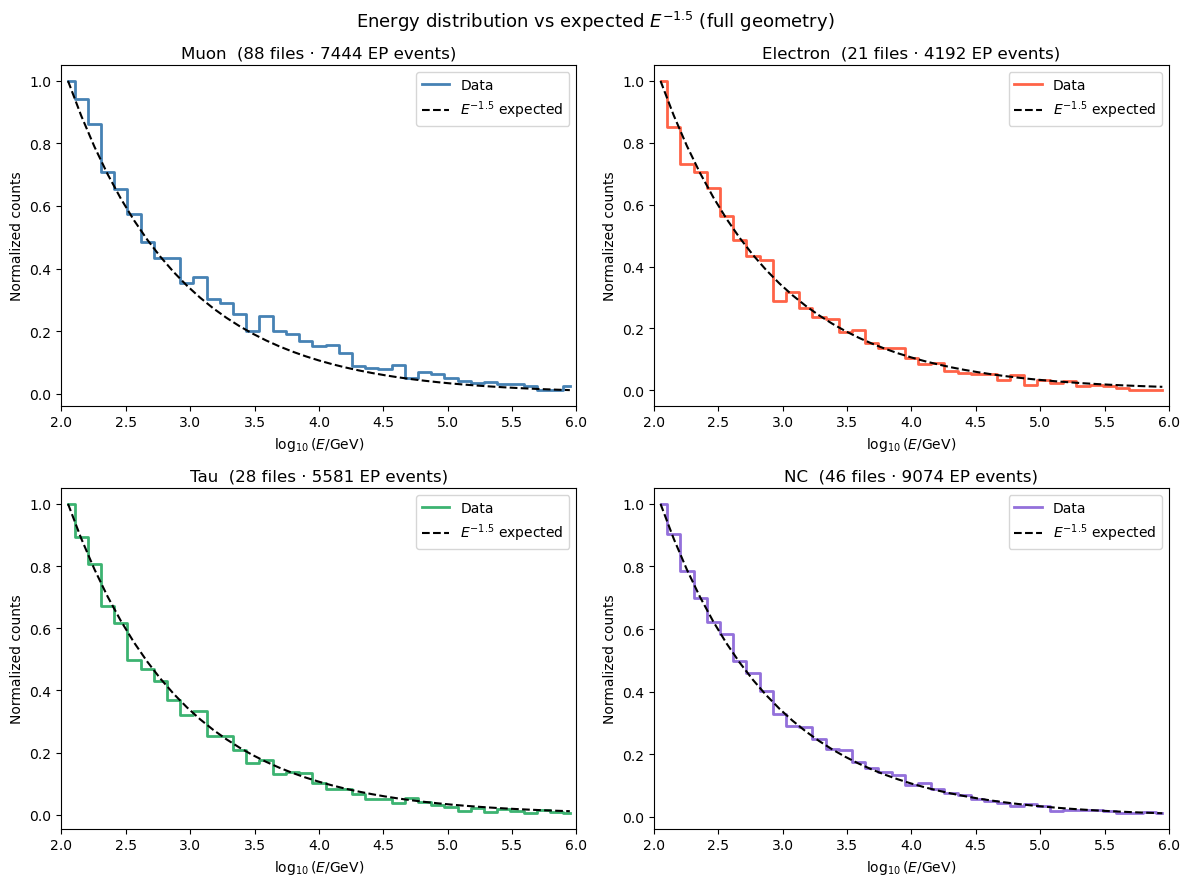

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

colors = {"Muon": "steelblue", "Electron": "tomato", "Tau": "mediumseagreen", "NC": "mediumpurple"}

for ax, (flavor, df) in zip(axes, event_dfs.items()):
    E = df["energy"].to_numpy()
    log_E = np.log10(E)
    bins = np.linspace(2, 6, 40)

    counts, edges = np.histogram(log_E, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])

    counts_norm = counts / counts.max()

    E_centers = 10**centers
    expected = E_centers**(-0.5)
    expected_norm = expected / expected.max()

    ax.step(centers, counts_norm, where="mid", color=colors[flavor], label="Data", linewidth=2)
    ax.plot(centers, expected_norm, "k--", label=r"$E^{-1.5}$ expected", linewidth=1.5)

    ax.set_xlabel(r"$\log_{10}(E/\mathrm{GeV})$")
    ax.set_ylabel("Normalized counts")
    s = event_stats[flavor]
    ax.set_title(f"{flavor}  ({s['total_files']} files · {s['total_ep_ok']} EP events)")
    ax.legend()
    ax.set_xlim(2, 6)

plt.suptitle("Energy distribution vs expected $E^{-1.5}$ (full geometry)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/energy_distribution.png", dpi=150)
plt.show()

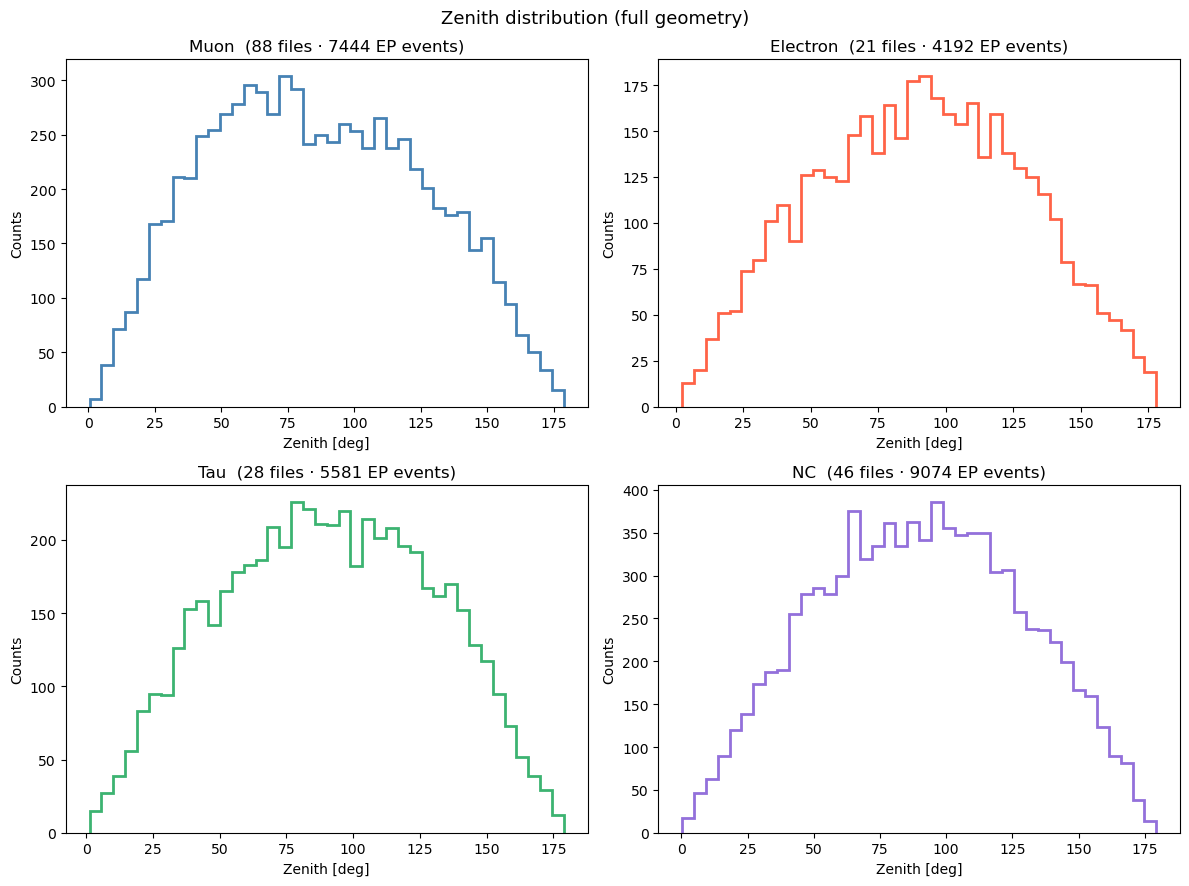

In [8]:
# Zenith
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
colors = {"Muon": "steelblue", "Electron": "tomato", "Tau": "mediumseagreen", "NC": "mediumpurple"}

for ax, (flavor, df) in zip(axes, event_dfs.items()):
    ax.hist(df["zenith"], bins=40, color=colors[flavor], histtype="step", linewidth=2)
    ax.set_xlabel("Zenith [deg]")
    ax.set_ylabel("Counts")
    s = event_stats[flavor]
    ax.set_title(f"{flavor}  ({s['total_files']} files · {s['total_ep_ok']} EP events)")

plt.suptitle("Zenith distribution (full geometry)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/zenith_distribution.png", dpi=150)
plt.show()

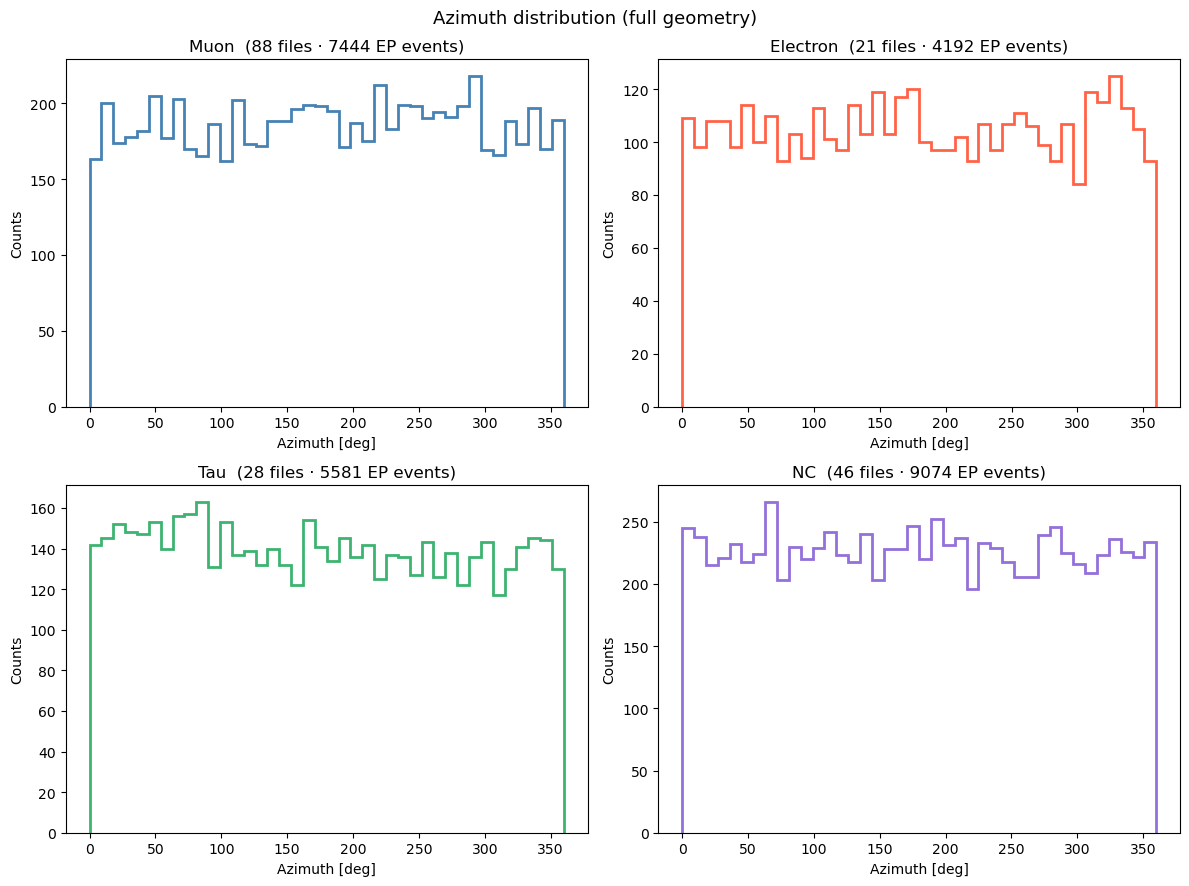

In [9]:
# Azimuth
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (flavor, df) in zip(axes, event_dfs.items()):
    ax.hist(df["azimuth"], bins=40, color=colors[flavor], histtype="step", linewidth=2)
    ax.set_xlabel("Azimuth [deg]")
    ax.set_ylabel("Counts")
    s = event_stats[flavor]
    ax.set_title(f"{flavor}  ({s['total_files']} files · {s['total_ep_ok']} EP events)")

plt.suptitle("Azimuth distribution (full geometry)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/azimuth_distribution_full_geometry.png", dpi=150)
plt.show()

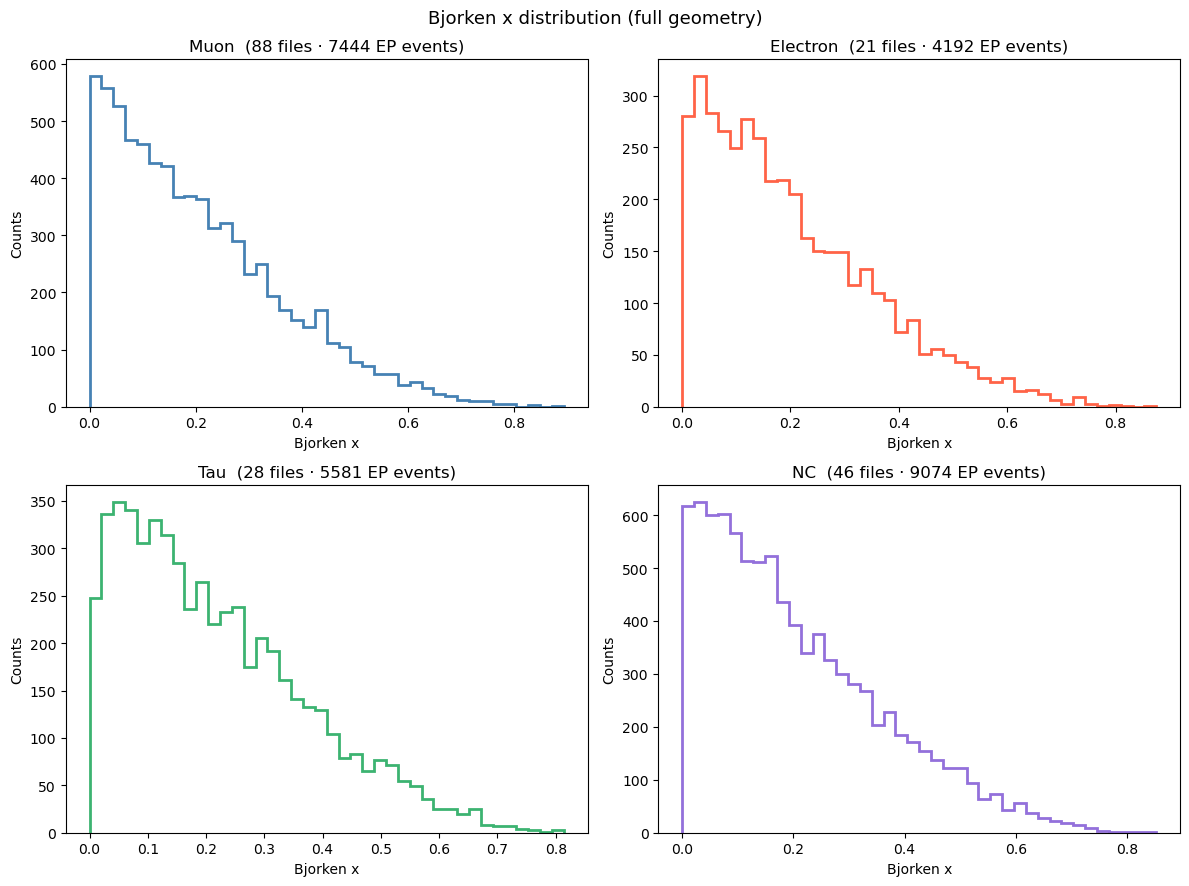

In [10]:
# Bjorken X
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (flavor, df) in zip(axes, event_dfs.items()):
    bx = df["bjorken_x"].dropna()
    ax.hist(bx, bins=40, color=colors[flavor], histtype="step", linewidth=2)
    ax.set_xlabel("Bjorken x")
    ax.set_ylabel("Counts")
    s = event_stats[flavor]
    ax.set_title(f"{flavor}  ({s['total_files']} files · {s['total_ep_ok']} EP events)")

plt.suptitle("Bjorken x distribution (full geometry)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/bjorken_x_distribution.png", dpi=150)
plt.show()

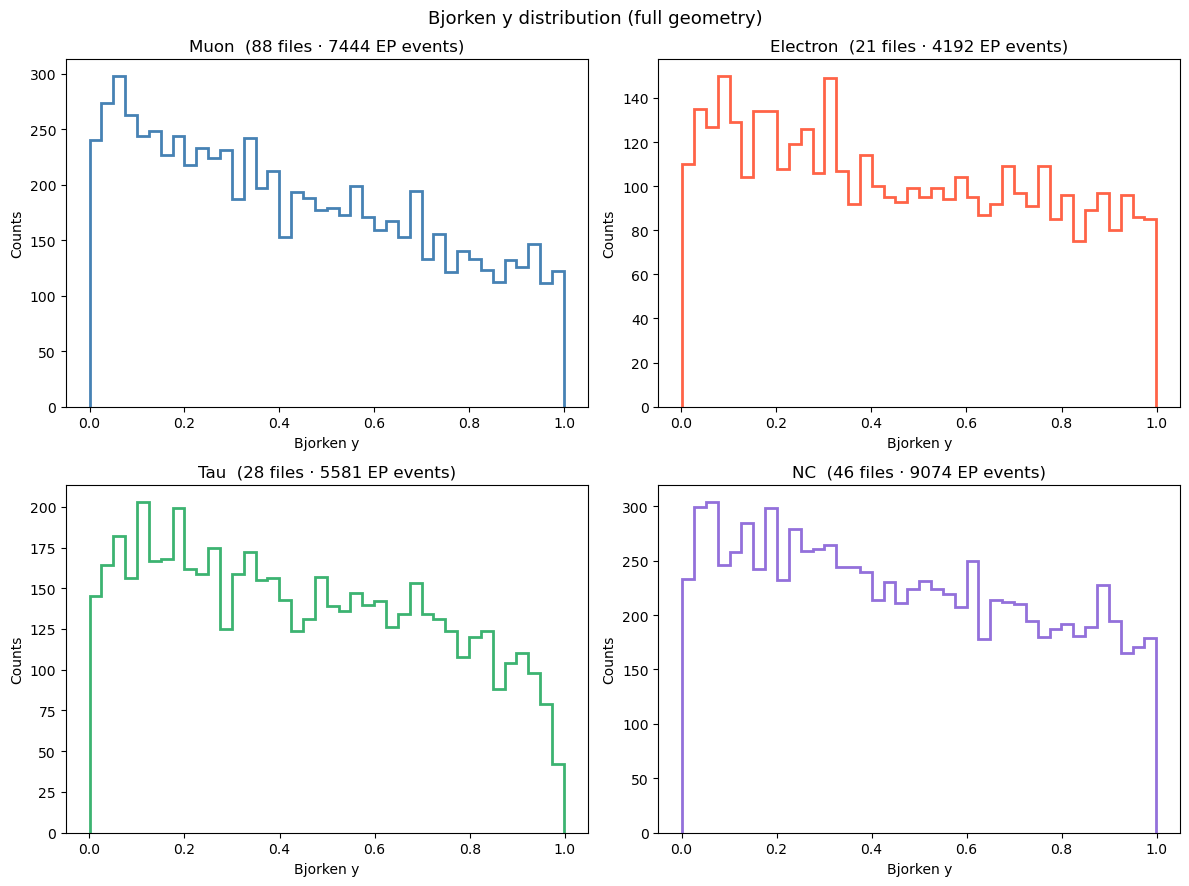

In [11]:
# Bjorken Y
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (flavor, df) in zip(axes, event_dfs.items()):
    by = df["bjorken_y"].dropna()
    ax.hist(by, bins=40, color=colors[flavor], histtype="step", linewidth=2)
    ax.set_xlabel("Bjorken y")
    ax.set_ylabel("Counts")
    s = event_stats[flavor]
    ax.set_title(f"{flavor}  ({s['total_files']} files · {s['total_ep_ok']} EP events)")

plt.suptitle("Bjorken y distribution (full geometry)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/bjorken_y_distribution.png", dpi=150)
plt.show()

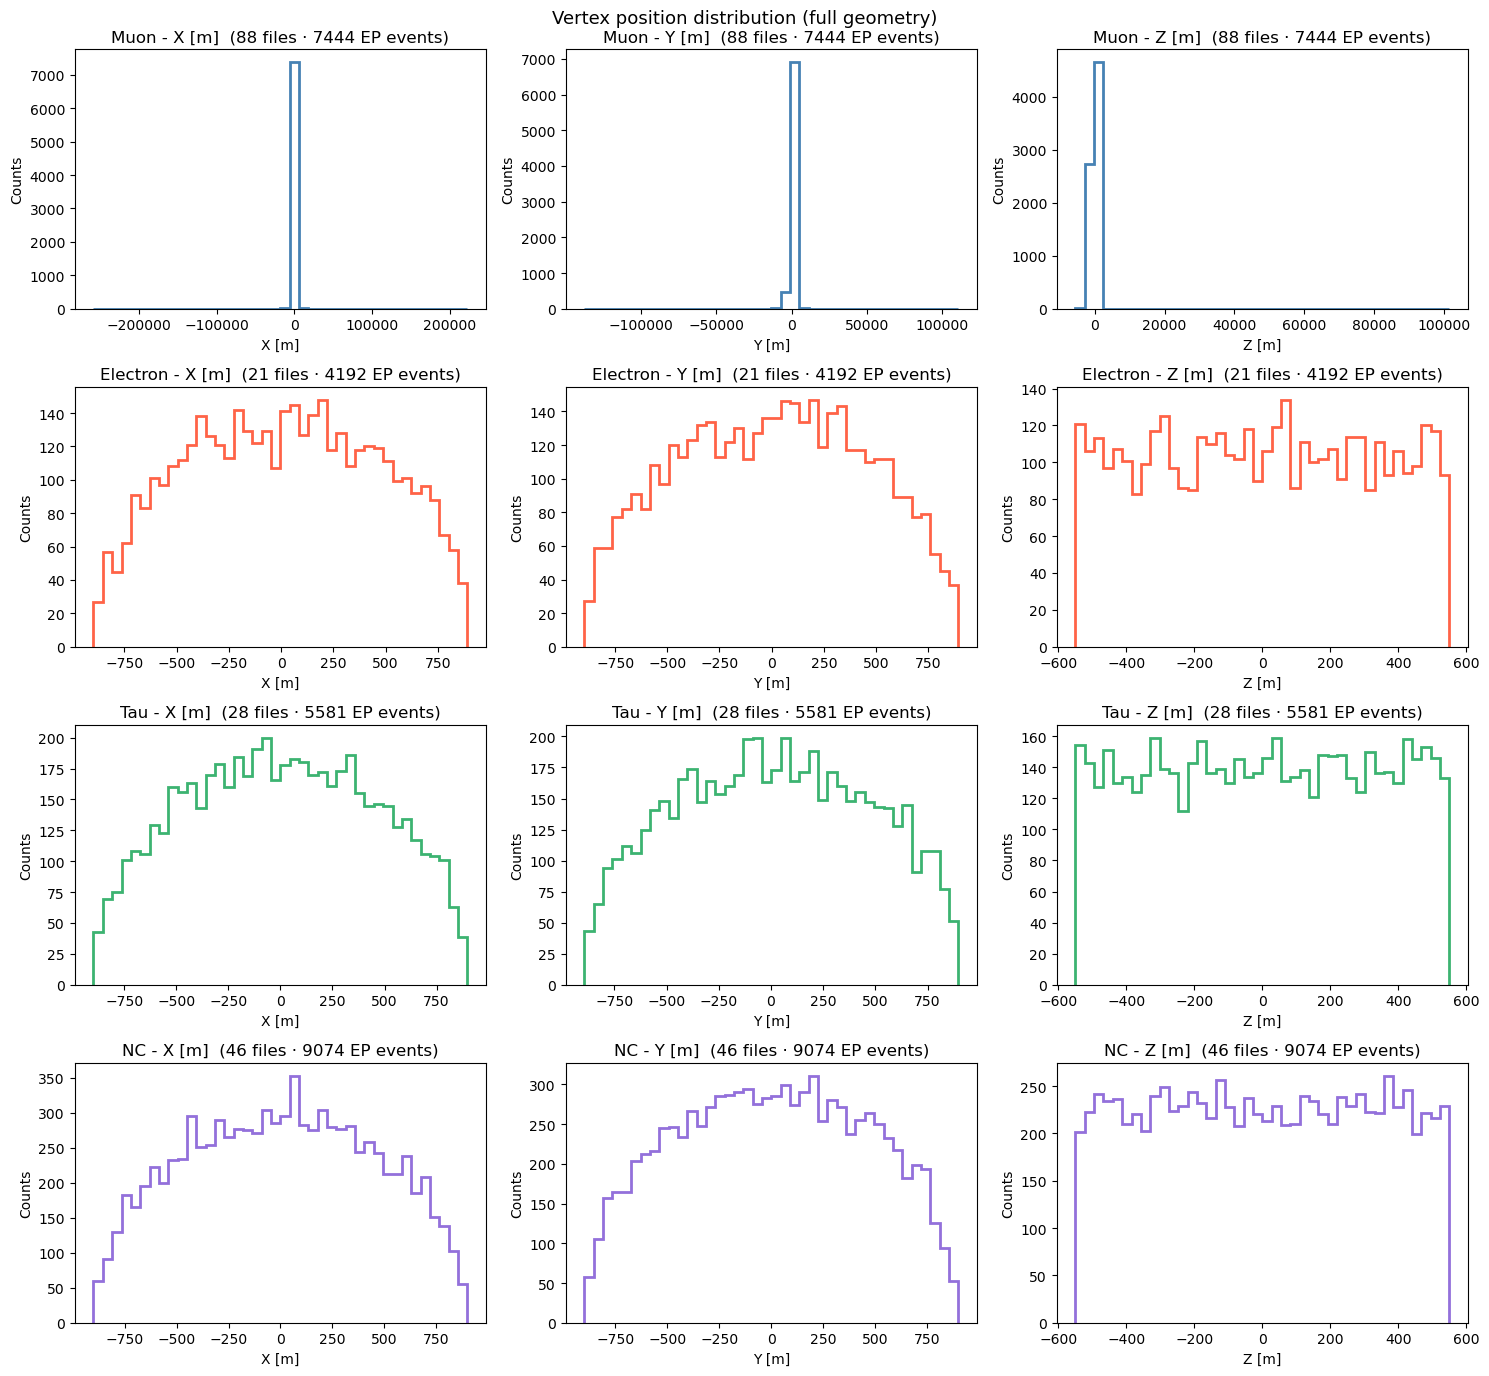

In [ ]:
# Position X, Y, Z
fig, axes = plt.subplots(4, 3, figsize=(15, 14))

for row, (flavor, df) in enumerate(event_dfs.items()):
    s = event_stats[flavor]
    for col, (key, label) in enumerate([("x", "X [m]"), ("y", "Y [m]"), ("z", "Z [m]")]):
        ax = axes[row, col]
        ax.hist(df[key], bins=40, color=colors[flavor], histtype="step", linewidth=2)
        ax.set_xlabel(label)
        ax.set_ylabel("Counts")
        ax.set_title(f"{flavor} - {label}  ({s['total_files']} files · {s['total_ep_ok']} EP events)")

plt.suptitle("Vertex position distribution (full geometry)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/position_distribution.png", dpi=150)
plt.show()